In [4]:
from astropy.table import Table
import os
import numpy as np

out_dir = "/data/hetdex/u/bgrashey/data/"        
name = "full_catalog.fits"
name = "Mawatari_match.fits"
name = "neuer_Katalog.fits"
out_path = os.path.join(out_dir, name)

tbl = Table.read(out_path)
Catalog = tbl.to_pandas()


Catalog = Catalog[(Catalog["PROB"]>0.5)]
Catalog

,RA,DEC,REDSHIFT,EW,EW_OBS,EW_ERR,FLUX,FLUX_ERR,CONT,CONT_ERR,PROB
1,334.228478,0.187487,2.038348,0.992560,3.016163,0.826601,2.419696e-14,6.605812e-15,8.022431e-15,1.927727e-16,1.000000
2,334.228483,0.187483,2.052605,0.576584,1.760385,1.125944,1.412182e-14,9.027284e-15,8.022010e-15,1.714964e-16,1.000000
7,334.241747,0.379102,1.957909,0.652791,1.931871,1.078027,8.776652e-15,4.891564e-15,4.543083e-15,1.254897e-16,1.000000
9,334.427047,0.199009,2.038264,1.430984,4.348416,0.921197,5.631662e-14,1.181365e-14,1.295106e-14,3.830325e-16,1.000000
10,334.427057,0.199008,2.052575,0.676209,2.064377,0.851674,2.674482e-14,1.101867e-14,1.295539e-14,2.795895e-16,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
9495,334.304363,0.399098,2.731989,8.738051,32.617379,5.534887,4.853327e-17,8.196095e-18,1.487957e-18,2.472496e-20,0.632521
9497,334.229448,0.313843,2.119201,57.833433,180.449418,177.834684,4.312361e-17,1.150525e-17,2.389789e-19,2.267215e-19,1.000000
9499,334.349074,0.133444,3.390553,74.602479,327.510325,312.552273,2.914715e-17,4.820891e-18,8.899613e-20,8.364620e-20,0.999911
9500,334.229963,0.238253,2.138045,48.764827,153.143769,249.584236,2.069485e-17,9.806470e-18,1.351335e-19,2.107173e-19,1.000000


In [11]:
"""
cont, err, cont_hsc, hsc_err = Catalog["CONT"], Catalog["CONT_ERR"], Catalog["CONT_HSC"], Catalog["CONT_HSC_ERR"]

flux = Catalog["FLUX"]

import matplotlib.pyplot as plt

plt.scatter(cont_hsc, cont_hsc/hsc_err, s=1, label="HSC data")
plt.scatter(cont, cont/err * 10, color="r", s=1, label="Virus data")
plt.xscale("log")
plt.legend(loc="best")
plt.xlabel("Continuum flux")
plt.ylabel("S/N in continuum flux")
plt.show()
"""

'\ncont, err, cont_hsc, hsc_err = Catalog["CONT"], Catalog["CONT_ERR"], Catalog["CONT_HSC"], Catalog["CONT_HSC_ERR"]\n\nflux = Catalog["FLUX"]\n\nimport matplotlib.pyplot as plt\n\nplt.scatter(cont_hsc, cont_hsc/hsc_err, s=1, label="HSC data")\nplt.scatter(cont, cont/err * 10, color="r", s=1, label="Virus data")\nplt.xscale("log")\nplt.legend(loc="best")\nplt.xlabel("Continuum flux")\nplt.ylabel("S/N in continuum flux")\nplt.show()\n'

In [12]:
from tools.cubes import mag_AB

m = mag_AB(2.166535e-17)
m_thresh = 26.5


In [11]:
mask_prob = Catalog["PROB"] > 0.5
Catalog_LAE = Catalog[mask_prob]

redshifts = Catalog_LAE["REDSHIFT"]
mask = (Catalog_LAE["REDSHIFT"] > 2.75) & (Catalog_LAE["REDSHIFT"] < 3.4)

Catalog_LAE = Catalog_LAE[mask]
print(type(Catalog_LAE))
print(min(redshifts), max(redshifts))
Catalog_LAE = Catalog_LAE.copy()

<class 'pandas.core.frame.DataFrame'>
1.8624775409698486 3.5193581581115723


In [12]:
import os
import numpy as np
import pandas as pd

dir = "/data/hetdex/u/bgrashey/data"
file = "mawatari.txt"

catalog_file = os.path.join(dir, file)

if os.path.exists(catalog_file):
    colspecs = [
    (0, 28),   # Name
    (29, 39),  # RAdeg
    (40, 48),  # DEdeg
    (49, 55),  # zspec
    (56, 57),  # q_zspec
    (58, 69),  # r_zspec
    (70, 77),  # Object
    (78, 84),  # AGN
    (85, 95)   # r_AGN
    ]

    names = ['Name', 'RAdeg', 'DEdeg', 'zspec', 'q_zspec',
             'r_zspec', 'Object', 'AGN', 'r_AGN']

    
    mawatari = pd.read_fwf(
        catalog_file,
        colspecs=colspecs,
        names=names,
        skiprows=107
    )
  
else:
    print(f"No file called {file}")
    
LAE_mask = (mawatari["Object"] == "LAE") #| (mawatari["Object"] == "LAB")

ra_min  = min(Catalog_LAE["RA"]) #334.1541667  
ra_max  = max(Catalog_LAE["RA"]) # 334.4608333                                 
dec_min = min(Catalog_LAE["DEC"]) # 0.1105556                        
dec_max = max(Catalog_LAE["DEC"]) # 0.4463611

FoV_mask = (
    mawatari["RAdeg"].between(ra_min, ra_max) &
    mawatari["DEdeg"].between(dec_min, dec_max)
)

mask = LAE_mask & FoV_mask
cat = mawatari[mask]
z = cat["zspec"]
cat

,Name,RAdeg,DEdeg,zspec,q_zspec,r_zspec,Object,AGN,r_AGN
0,[NSS2011] LAE 001,334.385249,0.192603,3.0690,A,Erb+14,LAE,NaN,NaN
1,[NSS2011] LAE 003,334.353262,0.288155,3.0965,A,Erb+14,LAE,NaN,NaN
2,[NSS2011] LAE 004,334.366804,0.241537,3.0788,A,Erb+14,LAE,NaN,NaN
3,[NSS2011] LAE 006,334.353453,0.187894,3.0691,A,Erb+14,LAE,NaN,NaN
4,[NSS2011] LAE 008,334.338025,0.257640,3.0692,A,Erb+14,LAE,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1927,SSA22oIM J221725.7+002535,334.357241,0.426298,3.1149,B,oIMACS,LAE,NaN,NaN
1928,SSA22oIM J221718.6+001023,334.327567,0.173125,3.0814,A,oIMACS,LAE,NaN,NaN
1929,SSA22oIM J221742.1+002102,334.425545,0.350666,3.1068,B,oIMACS,LAE,NaN,NaN
1933,SSA22oIM J221640.2+001803,334.167447,0.300726,3.0753,B,oIMACS,LAE,NaN,NaN


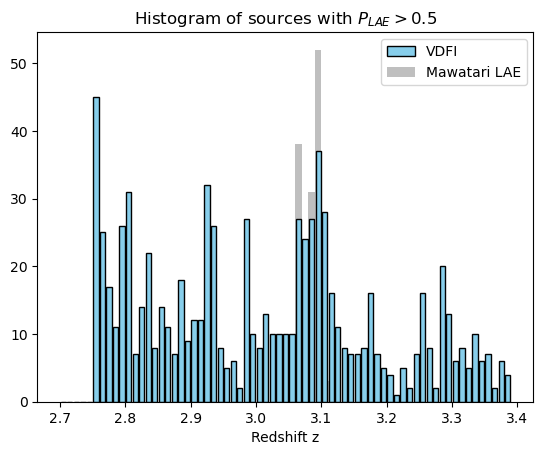

In [13]:
import matplotlib.pyplot as plt

bins = np.arange(2.7, 3.4, 0.01)

plt.hist(Catalog_LAE["REDSHIFT"], bins=bins, alpha=1, color="skyblue",
        edgecolor="black", label="VDFI", rwidth=0.8, zorder=2)
plt.hist(z, bins=bins, color="grey", alpha=0.5, label="Mawatari LAE",
         zorder=1)

plt.xlabel("Redshift z")
plt.title(r"Histogram of sources with $P_{LAE} > 0.5$")
plt.legend(loc="best")
#plt.xlim(3.0,3.2)
plt.show()

In [3]:
import os 
from astropy.wcs import WCS
from astropy.io import fits
from astropy.table import Table, Column
import numpy as np


directory = "/data/hetdex/u/mxhf/VDFI/VirusDeep/stackmf/ssa22_fullfp/"
file_stack = "ssa22_fullfp_stack.fits"

cube = os.path.join(directory, file_stack)

Catalog = Table.from_pandas(Catalog_LAE.copy()) if hasattr(Catalog_LAE["RA"], "isnull") else Table(Catalog_LAE)

# Better: just build the Table directly from arrays, bypassing pandas entirely
with fits.open(cube) as hdul:
    header = hdul[0].header

wcs = WCS(header)
lambda0 = 1216.0

wave  = lambda0 * (1 + np.asarray(Catalog["REDSHIFT"], dtype=float))
ra    = np.asarray(Catalog["RA"],  dtype=float)
dec   = np.asarray(Catalog["DEC"], dtype=float)

pix   = wcs.all_world2pix(np.column_stack([ra, dec, wave]), 0)

Catalog["WAVE"]  = wave
Catalog["X"]     = pix[:, 0]
Catalog["Y"]     = pix[:, 1]
Catalog["SLICE"] = pix[:, 2]

Catalog.write("/data/hetdex/u/bgrashey/data/lae_catalog.fits", overwrite=True)

In [4]:
import os
import warnings
import numpy as np
from astropy.io import fits
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from scipy.spatial import cKDTree
from scipy.ndimage import map_coordinates
from tqdm import tqdm
from scipy.ndimage import gaussian_filter


directory = "/data/hetdex/u/mxhf/VDFI/VirusDeep/stackmf/ssa22_fullfp/"
file_stack = "ssa22_fullfp_stack.fits"

out_dir      = "/data/hetdex/u/bgrashey/data/"
catalog_name = "lae_catalog.fits"

CUBE_FILE    = os.path.join(directory, file_stack)
CUBE_EXT     = 0
CATALOG_FILE = os.path.join(out_dir, catalog_name)
CATALOG_EXT  = 1

COL_RA       = "RA"
COL_DEC      = "DEC"
COL_Z        = "REDSHIFT"
COL_WAVE     = "WAVE"
COL_X        = "X"
COL_Y        = "Y"
COL_ZPIX     = "SLICE"

PIXSCALE_ARCSEC = 0.5
REST_WAVE       = 1216.0
KPC_PER_PIX_OUT = 2.5

STACK_SIZE      = 80
STACK_DEPTH     = 15
N_DENSITY_BINS  = 3
N_Z_BINS        = 3
KNN_K           = 10


def sky_to_comoving_xyz(ra_deg, dec_deg, redshift):
    ra  = np.deg2rad(np.asarray(ra_deg))
    dec = np.deg2rad(np.asarray(dec_deg))
    z   = np.asarray(redshift)
    Dc  = cosmo.comoving_distance(z).to_value(u.Mpc)
    x   = Dc * np.cos(dec) * np.cos(ra)
    y   = Dc * np.cos(dec) * np.sin(ra)
    zc  = Dc * np.sin(dec)
    return np.column_stack([x, y, zc])


def local_density_knn(ra_deg, dec_deg, redshift, k=KNN_K):
    pts = sky_to_comoving_xyz(ra_deg, dec_deg, redshift)
    tree = cKDTree(pts)
    dists, _ = tree.query(pts, k=k + 1)
    rk = dists[:, k]
    volume = (4.0 / 3.0) * np.pi * rk**3
    rho = k / volume
    return rho, rk


def kpc_per_arcsec_from_wavelength(wavelength_angstrom, rest_wavelength=REST_WAVE):
    z = float(wavelength_angstrom) / float(rest_wavelength) - 1.0
    if not np.isfinite(z) or z < 0:
        raise ValueError(f"Ungültige Rotverschiebung z={z:.4f} für λ={wavelength_angstrom} Å")
    kpc_per_arcsec = cosmo.kpc_comoving_per_arcmin(z).to(u.kpc / u.arcsec).value
    return z, float(kpc_per_arcsec)


def _nan_map_coordinates_2d(img, y_coords, x_coords, order=1, cval=np.nan):
    valid  = np.isfinite(img).astype(float)
    filled = np.nan_to_num(img, nan=0.0)
    coords = np.array([y_coords, x_coords])
    vals = map_coordinates(filled, coords, order=order, mode="constant", cval=0.0,
                           prefilter=(order > 1))
    wgt  = map_coordinates(valid,  coords, order=1,     mode="constant", cval=0.0,
                           prefilter=False)
    with np.errstate(invalid="ignore", divide="ignore"):
        out = vals / wgt
    out[wgt < 1e-6] = cval
    return out


def extract_centered_cutout_fixed_kpc(
    cube, x, y, zpix, wavelength_angstrom,
    pixscale_arcsec=PIXSCALE_ARCSEC,
    size_out=STACK_SIZE,
    depth=STACK_DEPTH,
    kpc_per_pix_out=KPC_PER_PIX_OUT,
    order_zoom=1,
    rest_wavelength=REST_WAVE,
    bad_pixel_mask=None,
):
    """
    Extract a cutout resampled to a fixed physical scale.

    zeros are no longer blanket-converted to NaN; pass a bad_pixel_mask
    if you need to flag specific pixels.
    """
    nz, ny, nx = cube.shape
    z0   = int(np.round(zpix))
    zmin = z0 - depth // 2
    zmax = z0 + depth // 2 + 1
    if zmin < 0 or zmax > nz:
        return None, None

    _, kpc_per_arcsec = kpc_per_arcsec_from_wavelength(wavelength_angstrom,
                                                        rest_wavelength)
    kpc_per_pix_in = float(pixscale_arcsec) * float(kpc_per_arcsec)
    zoom_factor    = kpc_per_pix_in / float(kpc_per_pix_out)
    if zoom_factor <= 0 or not np.isfinite(zoom_factor):
        return None, None

    c       = (size_out - 1) / 2.0
    margin  = 3 if order_zoom > 1 else 2
    half_in = int(np.ceil(c / zoom_factor)) + margin

    # clamp to cube bounds
    x0, y0 = int(np.floor(x)), int(np.floor(y))
    xmin = max(0, x0 - half_in)
    xmax = min(nx, x0 + half_in + 1)
    ymin = max(0, y0 - half_in)
    ymax = min(ny, y0 + half_in + 1)

    # bail out if the clamped window is too small for the requested output
    if (xmax - xmin) < 2 or (ymax - ymin) < 2:
        return None, None

    x_src_local = x - xmin
    y_src_local = y - ymin
    yy, xx      = np.indices((size_out, size_out), dtype=float)
    x_in = x_src_local + (xx - c) / zoom_factor
    y_in = y_src_local + (yy - c) / zoom_factor

    # check interpolation coords stay inside the local patch
    if (x_in.min() < 0 or x_in.max() >= (xmax - xmin) or
            y_in.min() < 0 or y_in.max() >= (ymax - ymin)):
        return None, None

    planes = []
    for zz in range(zmin, zmax):
        img = cube[zz, ymin:ymax, xmin:xmax].astype(float, copy=False)
        if bad_pixel_mask is not None:
            img = img.copy()
            img[bad_pixel_mask[zz, ymin:ymax, xmin:xmax]] = np.nan
        planes.append(_nan_map_coordinates_2d(img, y_in, x_in, order=order_zoom))

    return np.asarray(planes, dtype=float), zoom_factor


print("Lade Datenwürfel …")
with fits.open(CUBE_FILE) as hdul:
    cube   = hdul[CUBE_EXT].data.astype(float)
    header = hdul[CUBE_EXT].header
print(f"  Würfel-Shape: {cube.shape}  (nz, ny, nx)")

print("Lade Katalog …")
with fits.open(CATALOG_FILE) as hdul:
    cat = hdul[CATALOG_EXT].data
ra    = np.asarray(cat[COL_RA],    dtype=float)
dec   = np.asarray(cat[COL_DEC],   dtype=float)
zred  = np.asarray(cat[COL_Z],     dtype=float)
wave  = np.asarray(cat[COL_WAVE],  dtype=float)
x_pix = np.asarray(cat[COL_X],    dtype=float)
y_pix = np.asarray(cat[COL_Y],    dtype=float)
z_pix = np.asarray(cat[COL_ZPIX], dtype=float)
N     = len(ra)
print(f"  {N} Quellen geladen.")


print(f"\nBerechne lokale Dichte (kNN, k={KNN_K}) …")
density, rk = local_density_knn(ra, dec, zred, k=KNN_K)
print(f"  Dichte-Bereich: {density.min():.4f} – {density.max():.4f} Gal/Mpc³")


print("\nErstelle Dichte-Cube …")
density_cube = np.zeros(cube.shape, dtype=float)
nz, ny, nx   = cube.shape

valid_mask = (
    np.isfinite(x_pix) & np.isfinite(y_pix) & np.isfinite(z_pix) &
    (x_pix >= 0) & (x_pix < nx) &
    (y_pix >= 0) & (y_pix < ny) &
    (z_pix >= 0) & (z_pix < nz)
)
xi = np.round(x_pix[valid_mask]).astype(int)
yi = np.round(y_pix[valid_mask]).astype(int)
zi = np.round(z_pix[valid_mask]).astype(int)
d  = density[valid_mask]

np.add.at(density_cube, (zi, yi, xi), d)


#fits.writeto(os.path.join(out_dir, "density_cube.fits"), density_cube, overwrite=True)
print("density_cube.fits gespeichert.")


def run_stack(indices, label):
    """Incremental nanmean stack — avoids holding all cutouts in RAM."""
    stack  = None
    weight = None
    skipped = 0

    for i in tqdm(indices, desc=f"Stack: {label}"):
        sub, _ = extract_centered_cutout_fixed_kpc(
            cube, x_pix[i], y_pix[i], z_pix[i],
            wavelength_angstrom=wave[i],
        )
        if sub is None:
            skipped += 1
            continue
        if stack is None:
            stack  = np.zeros_like(sub)
            weight = np.zeros_like(sub)
        valid = np.isfinite(sub)
        stack[valid]  += sub[valid]
        weight[valid] += 1

    if stack is None:
        print(f"  [{label}] Keine gültigen Ausschnitte!")
        return None

    with np.errstate(invalid="ignore"):
        result = np.where(weight > 0, stack / weight, np.nan)

    fname = os.path.join(out_dir, f"stack_{label}.fits")
    fits.writeto(fname, result, overwrite=True)
    n_used = int(np.max(weight)) if weight is not None else 0
    print(f"  [{label}] gestackt ({skipped} übersprungen) → {fname}")
    return result


print("\n── Stack 1: Alle Quellen ──")
run_stack(np.arange(N), "all")


print(f"\n── Stack 2: {N_DENSITY_BINS} Dichte-Bins ──")
density_bins = np.quantile(density, np.linspace(0, 1, N_DENSITY_BINS + 1))
print(f"  Dichte-Grenzen: {np.round(density_bins, 4)}")

for b in range(N_DENSITY_BINS):
    lo, hi = density_bins[b], density_bins[b + 1]
    if lo == hi:
        print(f"  Bin {b+1}: degenerate (lo == hi = {lo:.4f}), übersprungen.")
        continue
    mask = (density >= lo) & (density <= hi if b == N_DENSITY_BINS - 1 else density < hi)
    idx  = np.where(mask)[0]
    label = f"density_bin{b+1}_of{N_DENSITY_BINS}"
    print(f"  Bin {b+1}: {lo:.4f} – {hi:.4f} Gal/Mpc³  ({len(idx)} Quellen)")
    run_stack(idx, label)


print(f"\n── Stack 3: {N_Z_BINS} Redshift-Bins ──")
z_bins = np.quantile(zred, np.linspace(0, 1, N_Z_BINS + 1))
print(f"  Redshift-Grenzen: {np.round(z_bins, 4)}")

for b in range(N_Z_BINS):
    lo, hi = z_bins[b], z_bins[b + 1]
    if lo == hi:
        print(f"  Bin {b+1}: degenerate (lo == hi = {lo:.4f}), übersprungen.")
        continue
    mask = (zred >= lo) & (zred <= hi if b == N_Z_BINS - 1 else zred < hi)
    idx  = np.where(mask)[0]
    label = f"zbin{b+1}_of{N_Z_BINS}"
    print(f"  Bin {b+1}: z = {lo:.4f} – {hi:.4f}  ({len(idx)} Quellen)")
    run_stack(idx, label)


print("Fertig")


Lade Datenwürfel …
  Würfel-Shape: (1036, 2478, 2260)  (nz, ny, nx)
Lade Katalog …
  798 Quellen geladen.

Berechne lokale Dichte (kNN, k=10) …
  Dichte-Bereich: 0.0001 – 0.0538 Gal/Mpc³

Erstelle Dichte-Cube …
density_cube.fits gespeichert.

── Stack 1: Alle Quellen ──


Stack: all: 100%|██████████████████████████| 798/798 [00:12<00:00, 62.04it/s]


  [all] gestackt (0 übersprungen) → /data/hetdex/u/bgrashey/data/stack_all.fits

── Stack 2: 3 Dichte-Bins ──
  Dichte-Grenzen: [0.0001 0.001  0.0023 0.0538]
  Bin 1: 0.0001 – 0.0010 Gal/Mpc³  (266 Quellen)


Stack: density_bin1_of3: 100%|█████████████| 266/266 [00:04<00:00, 65.05it/s]


  [density_bin1_of3] gestackt (0 übersprungen) → /data/hetdex/u/bgrashey/data/stack_density_bin1_of3.fits
  Bin 2: 0.0010 – 0.0023 Gal/Mpc³  (266 Quellen)


...

  [zbin1_of3] gestackt (0 übersprungen) → /data/hetdex/u/bgrashey/data/stack_zbin1_of3.fits
  Bin 2: z = 2.9252 – 3.0962  (266 Quellen)


Stack: zbin2_of3: 100%|████████████████████| 266/266 [00:04<00:00, 65.80it/s]


  [zbin2_of3] gestackt (0 übersprungen) → /data/hetdex/u/bgrashey/data/stack_zbin2_of3.fits
  Bin 3: z = 3.0962 – 3.3955  (266 Quellen)


Stack: zbin3_of3: 100%|████████████████████| 266/266 [00:04<00:00, 65.62it/s]

  [zbin3_of3] gestackt (0 übersprungen) → /data/hetdex/u/bgrashey/data/stack_zbin3_of3.fits
Fertig


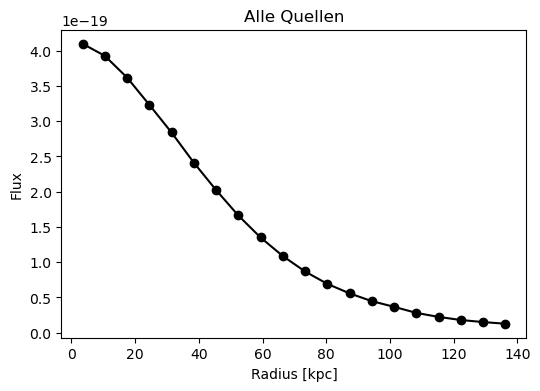

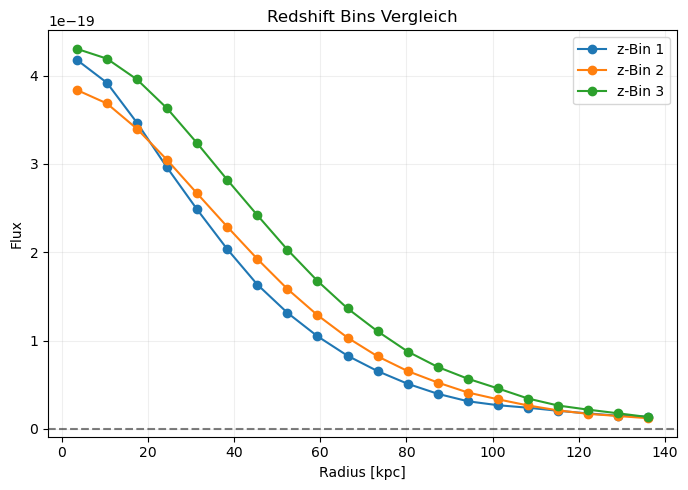

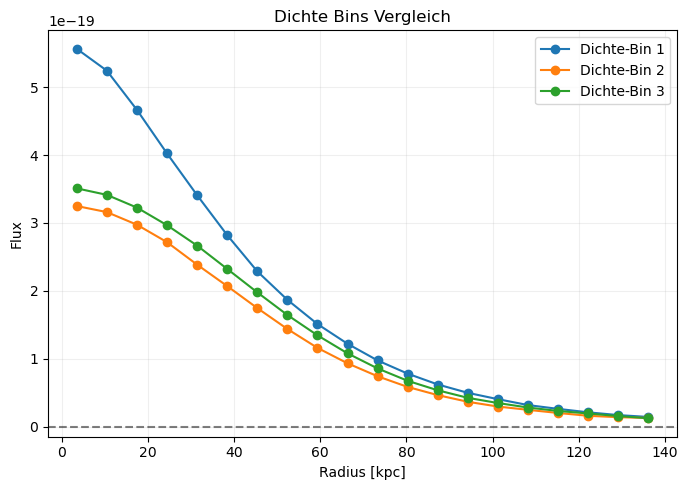

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from pathlib import Path

KPC_PER_PIX_OUT = 2.5
N_DENSITY_BINS = 3
N_Z_BINS = 3
OUTPUT_DIR = Path("/data/hetdex/u/bgrashey/data/")
FLUX_SCALE = 1e-17

def load_stack(fname):
    p = OUTPUT_DIR / fname
    if not p.exists(): return None
    with fits.open(p) as h: return h[0].data.astype(float)

def get_profile(stack):
    nz = stack.shape[0]
    img = np.nansum(stack[nz//2-2 : nz//2+3, :, :], axis=0)
    ny, nx = img.shape
    cy, cx = (ny-1)/2.0, (nx-1)/2.0
    yy, xx = np.indices((ny, nx))
    r_kpc = np.sqrt((xx-cx)**2 + (yy-cy)**2) * KPC_PER_PIX_OUT
    
    edges = np.linspace(0, r_kpc.max(), 21)
    r_mid = 0.5 * (edges[:-1] + edges[1:])
    prof = []
    for i in range(20):
        mask = (r_kpc >= edges[i]) & (r_kpc < edges[i+1])
        prof.append(np.nanmedian(img[mask]) * FLUX_SCALE)
    return img * FLUX_SCALE, r_mid, prof

def plot_comparison(stacks, labels, title, fname):
    valid = [(s, l) for s, l in zip(stacks, labels) if s is not None]
    if not valid: return
    
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    for s, l in valid:
        _, r, prof = get_profile(s)
        ax.plot(r, prof, "o-", label=l)
    
    ax.axhline(0, color="k", ls="--", alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("Radius [kpc]")
    ax.set_ylabel("Flux")
    #ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{fname}.png")
    plt.show()

# 1. Alle zusammen
s_all = load_stack("stack_all.fits")
if s_all is not None:
    img, r, prof = get_profile(s_all)
    plt.figure(figsize=(6,4))
    plt.plot(r, prof, "ko-")
    plt.title("Alle Quellen")
    plt.xlabel("Radius [kpc]")
    plt.ylabel("Flux")
    #plt.yscale("log")
    plt.show()

# 2. Redshift Bins Vergleich
z_stacks = [load_stack(f"stack_zbin{i+1}_of{N_Z_BINS}.fits") for i in range(N_Z_BINS)]
z_labels = [f"z-Bin {i+1}" for i in range(N_Z_BINS)]
plot_comparison(z_stacks, z_labels, "Redshift Bins Vergleich", "z_compare")

# 3. Dichte Bins Vergleich
d_stacks = [load_stack(f"stack_density_bin{i+1}_of{N_DENSITY_BINS}.fits") for i in range(N_DENSITY_BINS)]
d_labels = [f"Dichte-Bin {i+1}" for i in range(N_DENSITY_BINS)]
plot_comparison(d_stacks, d_labels, "Dichte Bins Vergleich", "d_compare")

In [7]:
"""
Halo Visualisierung
===================
Plot 1: Stack-Bilder nebeneinander (collapsed über spektrale Achse)
Plot 2: Radiale kpc-Profile — alle Quellen
Plot 3: Radiale kpc-Profile — Redshift-Bins
Plot 4: Radiale kpc-Profile — Dichte-Bins
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.io import fits
from pathlib import Path

# ──────────────────────────────────────────────
# KONFIGURATION — hier anpassen
# ──────────────────────────────────────────────

KPC_PER_PIX_OUT = 2.5
N_DENSITY_BINS  = 3
N_Z_BINS        = 3

CMAP_IMAGE      = "inferno"
VMIN_PCTL       = 1
VMAX_PCTL       = 99

OUTPUT_DIR      = Path(".") 


# ──────────────────────────────────────────────
# HILFSFUNKTIONEN
# ──────────────────────────────────────────────

def load_stack(fname):
    """Lädt einen FITS-Stack. Gibt None zurück wenn Datei fehlt."""
    p = OUTPUT_DIR / fname
    if not p.exists():
        print(f"  [Warnung] Datei nicht gefunden: {p}")
        return None
    with fits.open(p) as hdul:
        return hdul[0].data.astype(float)


def collapse(stack):
    """Median über spektrale Achse (axis=0) → 2D-Bild."""
    return np.nanmedian(stack, axis=0)


def radial_profile(image, kpc_per_pix=KPC_PER_PIX_OUT, n_bins=20):
    """
    Berechnet das radiale Medienprofil eines 2D-Bildes.

    Returns
    -------
    r_kpc : 1D array — Radius in kpc (Bin-Mittelpunkte)
    profile : 1D array — Median-Flusswert pro Annulus
    """
    ny, nx = image.shape
    cy, cx = (ny - 1) / 2.0, (nx - 1) / 2.0
    yy, xx = np.indices((ny, nx), dtype=float)
    r_pix  = np.sqrt((xx - cx)**2 + (yy - cy)**2)
    r_kpc  = r_pix * kpc_per_pix

    r_max  = r_kpc.max()
    edges  = np.linspace(0, r_max, n_bins + 1)
    r_mid  = 0.5 * (edges[:-1] + edges[1:])

    profile = np.full(n_bins, np.nan)
    for i in range(n_bins):
        mask = (r_kpc >= edges[i]) & (r_kpc < edges[i + 1])
        vals = image[mask]
        if np.any(np.isfinite(vals)):
            profile[i] = np.nanmedian(vals)

    return r_mid, profile


# ──────────────────────────────────────────────
# DATEN LADEN
# ──────────────────────────────────────────────

# Stack: alle
stack_all = load_stack("stack_all.fits")

# Stacks: Dichte-Bins
density_stacks = []
density_labels = []
for b in range(1, N_DENSITY_BINS + 1):
    s = load_stack(f"stack_density_bin{b}_of{N_DENSITY_BINS}.fits")
    density_stacks.append(s)
    density_labels.append(f"Dichte-Bin {b}")

# Stacks: Redshift-Bins
z_stacks = []
z_labels = []
for b in range(1, N_Z_BINS + 1):
    s = load_stack(f"stack_zbin{b}_of{N_Z_BINS}.fits")
    z_stacks.append(s)
    z_labels.append(f"z-Bin {b}")


# ──────────────────────────────────────────────
# PLOT 1: Stack-Bilder nebeneinander
# ──────────────────────────────────────────────

all_stacks_flat = (
    [("Alle", stack_all)]
    + list(zip(density_labels, density_stacks))
    + list(zip(z_labels, z_stacks))
)
# Nur gültige Stacks
all_stacks_flat = [(lbl, s) for lbl, s in all_stacks_flat if s is not None]

n_plots = len(all_stacks_flat)
ncols   = min(n_plots, 5)
nrows   = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows),
                         squeeze=False)
fig.suptitle("Median-Stacks (collapsed)", fontsize=14, y=1.01)

for idx, (label, stack) in enumerate(all_stacks_flat):
    ax   = axes[idx // ncols][idx % ncols]
    img  = collapse(stack)
    vmin = np.nanpercentile(img, VMIN_PCTL)
    vmax = np.nanpercentile(img, VMAX_PCTL)

    im = ax.imshow(img, origin="lower", cmap=CMAP_IMAGE,
                   vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(label, fontsize=10)

    # Achsenbeschriftung in kpc
    ny, nx = img.shape
    half_kpc = (nx // 2) * KPC_PER_PIX_OUT
    ticks_kpc = np.array([-1, -0.5, 0, 0.5, 1]) * half_kpc
    ticks_pix = ticks_kpc / KPC_PER_PIX_OUT + nx / 2
    ax.set_xticks(ticks_pix)
    ax.set_xticklabels([f"{t:.0f}" for t in ticks_kpc], fontsize=7)
    ax.set_yticks(ticks_pix)
    ax.set_yticklabels([f"{t:.0f}" for t in ticks_kpc], fontsize=7)
    ax.set_xlabel("kpc", fontsize=8)
    ax.set_ylabel("kpc", fontsize=8)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Leere Subplots ausblenden
for idx in range(len(all_stacks_flat), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot_stacks_images.pdf", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "plot_stacks_images.png", bbox_inches="tight", dpi=150)
print("→ plot_stacks_images.pdf/.png gespeichert")
plt.close()


# ──────────────────────────────────────────────
# PLOT-FUNKTION für radiale Profile
# ──────────────────────────────────────────────

colors_density = plt.cm.plasma(np.linspace(0.15, 0.85, N_DENSITY_BINS))
colors_z       = plt.cm.viridis(np.linspace(0.15, 0.85, N_Z_BINS))


def plot_profiles(stacks, labels, colors, title, fname):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_title(title, fontsize=13)

    for (label, stack), color in zip(zip(labels, stacks), colors):
        if stack is None:
            continue
        img = collapse(stack)
        r, prof = radial_profile(img)
        ax.plot(r, prof, marker="o", markersize=4, lw=1.8,
                label=label, color=color)

    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel("Radius [kpc]", fontsize=12)
    ax.set_ylabel("Median Flux", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{fname}.pdf", bbox_inches="tight", dpi=150)
    plt.savefig(OUTPUT_DIR / f"{fname}.png", bbox_inches="tight", dpi=150)
    print(f"→ {fname}.pdf/.png gespeichert")
    plt.close()


# ──────────────────────────────────────────────
# PLOT 2: Radiales Profil — alle Quellen
# ──────────────────────────────────────────────

if stack_all is not None:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_title("Radiales Profil — Alle Quellen", fontsize=13)
    img = collapse(stack_all)
    r, prof = radial_profile(img)
    ax.plot(r, prof, marker="o", markersize=5, lw=2, color="steelblue", label="Alle")
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel("Radius [kpc]", fontsize=12)
    ax.set_ylabel("Median Flux i", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plot_profile_all.pdf", bbox_inches="tight", dpi=150)
    plt.savefig(OUTPUT_DIR / "plot_profile_all.png", bbox_inches="tight", dpi=150)
    print("→ plot_profile_all.pdf/.png gespeichert")
    plt.close()


# ──────────────────────────────────────────────
# PLOT 3: Radiale Profile — Redshift-Bins
# ──────────────────────────────────────────────

plot_profiles(
    z_stacks, z_labels, colors_z,
    title="Radiale Profile — Redshift-Bins",
    fname="plot_profile_zbins",
)


# ──────────────────────────────────────────────
# PLOT 4: Radiale Profile — Dichte-Bins
# ──────────────────────────────────────────────

plot_profiles(
    density_stacks, density_labels, colors_density,
    title="Radiale Profile — Dichte-Bins",
    fname="plot_profile_densitybins",
)

print("\n✓ Alle Plots gespeichert.")

→ plot_stacks_images.pdf/.png gespeichert
→ plot_profile_all.pdf/.png gespeichert
→ plot_profile_zbins.pdf/.png gespeichert
→ plot_profile_densitybins.pdf/.png gespeichert

✓ Alle Plots gespeichert.


Filename: ../cubes/ssa22_fullfp_stack.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (2260, 2478, 1036)   float64   
  1                1 ImageHDU        24   (2260, 2478, 1036)   float64   


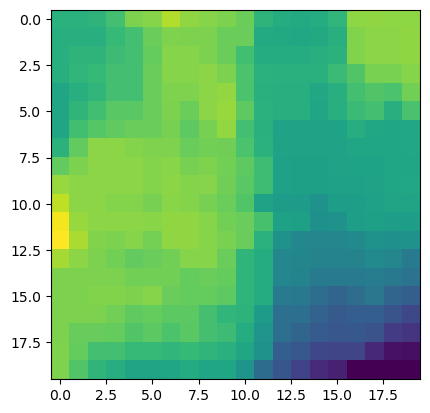

In [7]:
from astropy.io import fits
import matplotlib.pyplot as plt
with fits.open("../cubes/ssa22_fullfp_stack.fits") as hdul:
    hdul.info()
    data = hdul[1].data

plt.imshow(data[1000, 500:520, 500:520])